In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.append(str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.utils.seeds import set_seed
from src.data.simulation import simulate_var, make_stable_var_matrix
from src.var.fit import fit_var_ols
from src.var.stability import is_var_stable, var_eigenvalues
from src.var.forecast import forecast_var_mean
from src.innovations.residuals import residual_summary

set_seed(123)

In [2]:
k = 3
n_obs = 300

A = make_stable_var_matrix(k=k, scale=0.45, seed=123)

Sigma = np.array([
    [1.0, 0.3, 0.1],
    [0.3, 1.0, 0.2],
    [0.1, 0.2, 1.0],
])

y = simulate_var(A=A, Sigma=Sigma, n_obs=n_obs, seed=123)

print(y.shape)
print(A)

(300, 3)
[[-0.37465394 -0.1393082   0.48783324]
 [ 0.07347256  0.34855999  0.2185922 ]
 [-0.2410762   0.20527768 -0.11991828]]


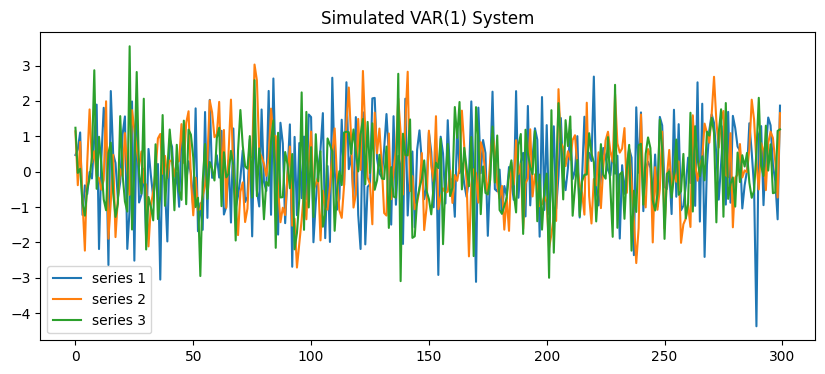

In [3]:
plt.figure(figsize=(10, 4))

for j in range(k):
    plt.plot(y[:, j], label=f"series {j+1}")

plt.legend()
plt.title("Simulated VAR(1) System")
plt.show()

In [4]:
fit = fit_var_ols(y, lags=1)

print("Estimated beta shape:", fit["beta"].shape)
print("Residual shape:", fit["residuals"].shape)
print("Estimated Sigma:")
print(fit["Sigma"])

Estimated beta shape: (4, 3)
Residual shape: (299, 3)
Estimated Sigma:
[[1.04859371 0.25816666 0.10581016]
 [0.25816666 0.9697768  0.25667548]
 [0.10581016 0.25667548 1.07762305]]


In [5]:
stable = is_var_stable(
    beta_no_intercept=fit["coefs"],
    k=k,
    lags=1,
)

eigvals = var_eigenvalues(
    beta_no_intercept=fit["coefs"],
    k=k,
    lags=1,
)

print("Stable:", stable)
print("Eigenvalues:", eigvals)
print("Max eigenvalue modulus:", np.max(np.abs(eigvals)))

Stable: True
Eigenvalues: [-0.31593213+0.37136993j -0.31593213-0.37136993j  0.35458889+0.j        ]
Max eigenvalue modulus: 0.4875743373709367


In [6]:
summary = residual_summary(fit["residuals"])

for key, value in summary.items():
    print(f"\n{key}:")
    print(value)


mean:
[-1.93082265e-17 -1.70803542e-17  9.65411326e-18]

std:
[1.0188412  0.97980301 1.03284776]

cov:
[[1.0380374  0.25556766 0.10474496]
 [0.25556766 0.96001394 0.2540915 ]
 [0.10474496 0.2540915  1.0667745 ]]

min:
[-4.02087284 -2.31071113 -3.31351752]

max:
[2.53851927 3.28818886 2.84256309]


In [7]:
h = 20
history = y[-1:].copy()

mean_forecast = forecast_var_mean(
    y_history=history,
    beta=fit["beta"],
    h=h,
    lags=1,
)

print(mean_forecast.shape)

(20, 3)


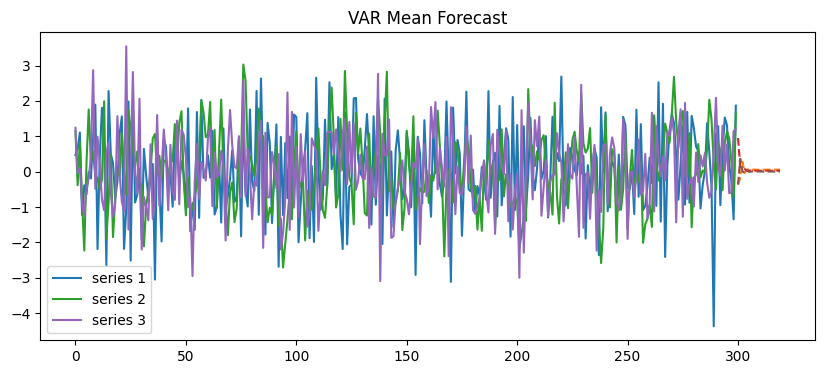

In [8]:
plt.figure(figsize=(10, 4))

for j in range(k):
    plt.plot(range(n_obs), y[:, j], label=f"series {j+1}")
    plt.plot(range(n_obs, n_obs + h), mean_forecast[:, j], linestyle="--")

plt.title("VAR Mean Forecast")
plt.legend()
plt.show()